# Klasifikasi Detak Jantung EKG untuk Deteksi Penyakit Jantung Koroner Menggunakan Random Forest

Nama: Rahman Nendhiarto

Nim: 2200018315

Kelas: B

Mata Kuliah: Pengenalan Pola

1. Import Library yang di perlukan dalam penelitian

In [ ]:
import pandas as pd
import numpy as np
from sklearn import svm
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
import seaborn as sns

2. Pemanggilan data dari drive

In [ ]:
import pandas as pd
from google.colab import drive
drive.mount('/content/drive')
# Membaca file csv
df = pd.read_csv('/content/drive/My Drive/Polamatkul/ECG Heartbeat Categorization Dataset/mitbih_test.csv')
# Tampilkan beberapa baris pertama dari DataFrame
print(df.head())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
   1.000000000000000000e+00  7.582644820213317871e-01  \
0                  0.908425                  0.783883   
1                  0.730088                  0.212389   
2                  1.000000                  0.910417   
3                  0.570470                  0.399329   
4                  1.000000                  0.923664   

   1.115702465176582336e-01  0.000000000000000000e+00  \
0                  0.531136                  0.362637   
1                  0.000000                  0.119469   
2                  0.681250                  0.472917   
3                  0.238255                  0.147651   
4                  0.656489                  0.195929   

   8.057851344347000122e-02  7.851240038871765137e-02  \
0                  0.366300                  0.344322   
1                  0.101770                  0.101770   
2             

2. Preprocessing data

  Membersihkan dan mengubah data agar siap untuk pelatihan model.


In [ ]:
# 1. Mengatasi missing values
df.fillna(df.mean(), inplace=True)

# Pisahkan fitur (semua kolom kecuali kolom terakhir) dan target (kolom terakhir)
feature_columns = df.iloc[:, :-1]
target_column = df.iloc[:, -1]

# 2. Normalisasi data
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
df_normalized = pd.DataFrame(scaler.fit_transform(feature_columns), columns=feature_columns.columns)

# 3. Smoothing data
window_size = 5
df_smoothed = df_normalized.rolling(window=window_size, center=True).mean().fillna(df_normalized)

# 4. Mengekstrak fitur statistik
def extract_features(dataframe):
    features = pd.DataFrame()
    features['mean'] = dataframe.mean(axis=1)
    features['std'] = dataframe.std(axis=1)
    features['min'] = dataframe.min(axis=1)
    features['max'] = dataframe.max(axis=1)
    features['median'] = dataframe.median(axis=1)
    features['range'] = features['max'] - features['min']
    features['variance'] = dataframe.var(axis=1)
    features['kurtosis'] = dataframe.kurtosis(axis=1)
    features['skewness'] = dataframe.skew(axis=1)
    return features

extracted_features = extract_features(df_smoothed)

# 5. Menggabungkan fitur dan target
extracted_features['target'] = target_column

# 6. Memisahkan fitur (X) dan target (y)
X = extracted_features.drop('target', axis=1)
y = extracted_features['target']

# 7. Oversampling data training menggunakan SMOTE
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X, y)
X_train_res = pd.DataFrame(X_res, columns=X.columns)
y_train_res = pd.Series(y_res, name='target')

# 8. Memisahkan data menjadi training dan testing set
X_train, X_test, y_train, y_test = train_test_split(X_train_res, y_train_res, test_size=0.2, random_state=42)

display(X_train.head())
display(X_test.head())
display(y_train.head())
display(y_test.head())
display(X_train_res.head())
display(y_train_res.head())

,mean,std,min,max,median,range,variance,kurtosis,skewness
71078,0.101452,0.154253,0.0,0.957414,0.000000,0.957414,0.023795,8.038052,2.323147
20795,0.230636,0.198964,0.0,0.852335,0.304020,0.852335,0.039587,-0.791718,0.208516
59060,0.095951,0.154621,0.0,0.952590,0.000000,0.952590,0.023908,8.610626,2.506671
67052,0.079169,0.139968,0.0,0.982338,0.000000,0.982338,0.019593,13.473966,3.030102
28260,0.182344,0.171419,0.0,0.945325,0.181329,0.945325,0.029390,1.598690,0.943600


,mean,std,min,max,median,range,variance,kurtosis,skewness
58343,0.099287,0.167187,0.0,0.976556,0.000000,0.976556,0.027981,7.010239,2.354294
10240,0.134796,0.119080,0.0,0.951199,0.130153,0.951199,0.014180,14.881752,2.740727
19002,0.267213,0.244823,0.0,0.619802,0.307675,0.619802,0.059938,-1.783245,-0.014553
8517,0.165390,0.155724,0.0,0.987815,0.169231,0.987815,0.024250,3.594402,1.154977
72665,0.092664,0.153997,0.0,0.941817,0.000000,0.941817,0.023722,9.978780,2.657640


,target
71078,3.0
20795,4.0
59060,3.0
67052,3.0
28260,1.0


,target
58343,3.0
10240,0.0
19002,2.0
8517,0.0
72665,3.0


,mean,std,min,max,median,range,variance,kurtosis,skewness
0,0.196747,0.237016,0.0,1.000000,0.029304,1.000000,0.056177,0.364402,1.009529
1,0.112188,0.137953,0.0,1.000000,0.101770,1.000000,0.019031,11.285541,2.525610
2,0.152490,0.155010,0.0,0.841797,0.141340,0.841797,0.024028,2.086769,1.087238
3,0.124618,0.142273,0.0,0.860112,0.103801,0.860112,0.020242,5.301369,1.818708
4,0.158771,0.163719,0.0,0.895975,0.146481,0.895975,0.026804,2.252178,1.143504


,target
0,0.0
1,0.0
2,0.0
3,0.0
4,0.0


3. Pembangunan model random forest

   Membuat dan melatih model Random Forest menggunakan data yang telah diproses.


In [ ]:
from sklearn.ensemble import RandomForestClassifier

# 2. Buat instance dari RandomForestClassifier
model_rf = RandomForestClassifier(n_estimators=100, random_state=42)

# 3. Latih model Random Forest
model_rf.fit(X_train_res, y_train_res)

RandomForestClassifier(random_state=42)

4. Evaluasi model

   Mengevaluasi kinerja model Random Forest menggunakan metrik yang relevan.


In [ ]:
from sklearn.metrics import classification_report

# 1. Lakukan prediksi pada data testing
y_pred_rf = model_rf.predict(X_test)

# 2. Gunakan classification_report untuk menghasilkan laporan evaluasi
report_rf = classification_report(y_test, y_pred_rf, output_dict=True)

# 3. Simpan laporan klasifikasi dalam DataFrame
df_report_rf = pd.DataFrame(report_rf).transpose()
display(df_report_rf)

,precision,recall,f1-score,support
0.0,1.0,1.0,1.0,3587.0
1.0,1.0,1.0,1.0,3723.0
2.0,1.0,1.0,1.0,3629.0
3.0,1.0,1.0,1.0,3666.0
4.0,1.0,1.0,1.0,3512.0
accuracy,1.0,1.0,1.0,1.0
macro avg,1.0,1.0,1.0,18117.0
weighted avg,1.0,1.0,1.0,18117.0


5. Menampilkan Hasil Akurasi Model Dari Random   Forest

In [ ]:
# Menampilkan akurasi model Random Forest dari classification_report
accuracy_rf = df_report_rf.loc['accuracy', 'precision']
print(f"Akurasi Model Random Forest: {accuracy_rf}")

Akurasi Model Random Forest: 1.0


# Hasil Akurasi yang di hasilkan dengan model Random Forest untuk penelitian ini adalah 100%

6. Visualisasi Distribusi untuk setiap kelas target

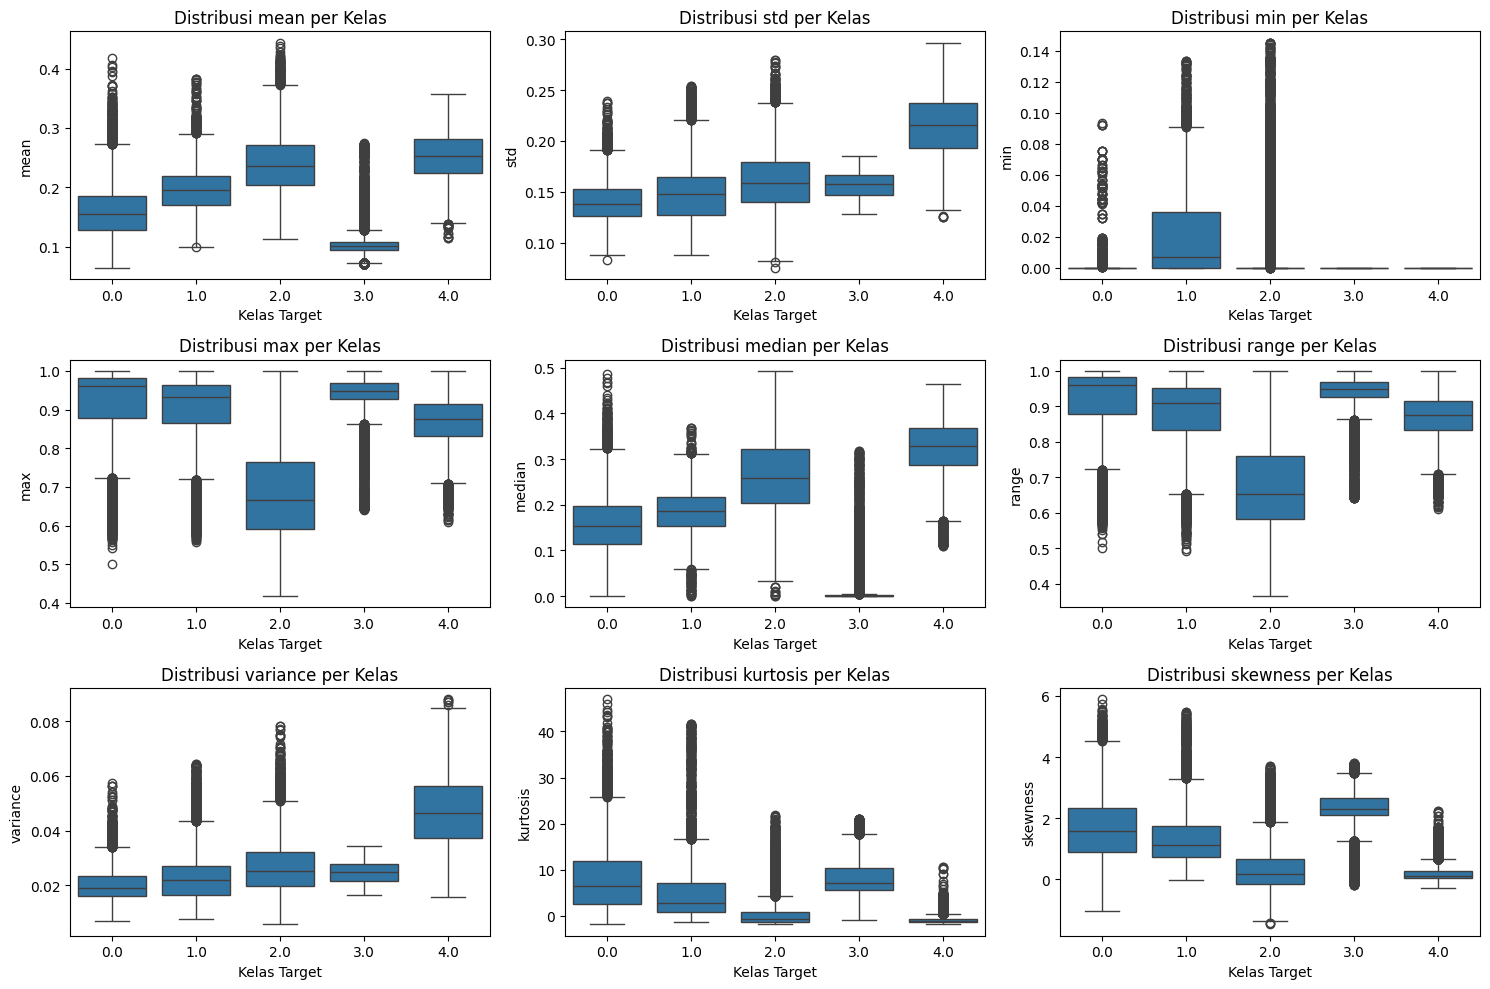

In [ ]:
# Visualisasikan distribusi fitur untuk setiap kelas target
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(15, 10))
axes = axes.flatten()

for i, col in enumerate(X_train_res.columns):
    sns.boxplot(x=y_train_res, y=X_train_res[col], ax=axes[i])
    axes[i].set_title(f'Distribusi {col} per Kelas')
    axes[i].set_xlabel('Kelas Target')
    axes[i].set_ylabel(col)

plt.tight_layout()
plt.show()

Dari visualisasi di atas, Anda dapat melihat distribusi setiap fitur yang diekstraksi (mean, std, min, max, median, range, variance, kurtosis, skewness) untuk setiap kelas target. Amati bagaimana distribusi fitur-fitur ini bervariasi di antara kelas-kelas. Perbedaan yang jelas dalam distribusi fitur antar kelas menunjukkan bahwa fitur-fitur ini informatif dan membantu model Random Forest dalam membedakan kelas-kelas target dengan akurasi tinggi. Misalnya, jika kotak (box) untuk sebuah fitur terpisah dengan baik di antara kelas-kelas, itu berarti fitur tersebut adalah prediktor yang kuat untuk klasifikasi.

8. Peta Korelasi

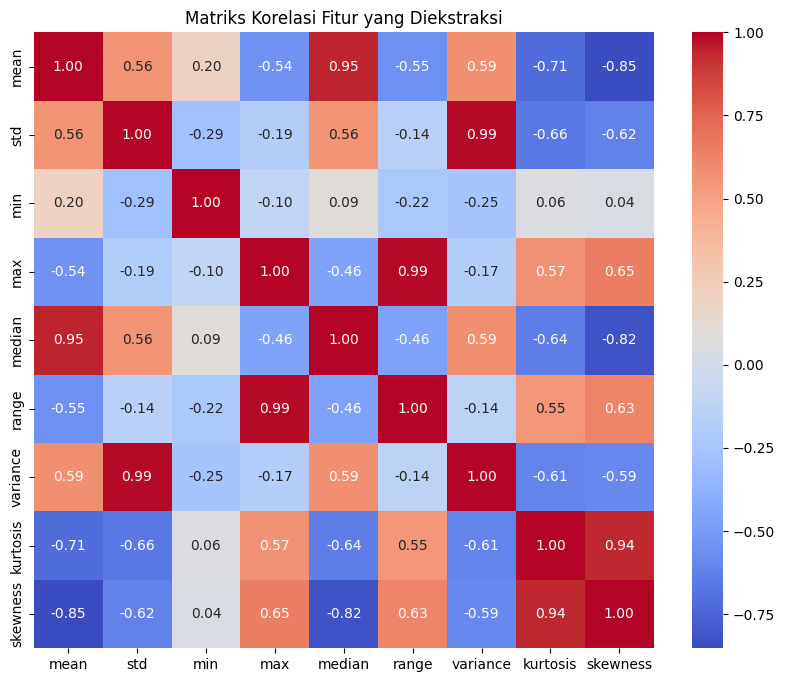

In [ ]:
# Visualisasikan matriks korelasi
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 8))
sns.heatmap(X_train_res.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matriks Korelasi Fitur yang Diekstraksi')
plt.show()

Visualisasi ini menampilkan matriks korelasi fitur yang sudah diekstraksi.

*   **Angka:** Menunjukkan kekuatan dan arah hubungan antar dua fitur (-1 sampai 1). Dekat 1 berarti korelasi positif kuat (satu naik, yang lain cenderung naik), dekat -1 berarti korelasi negatif kuat (satu naik, yang lain cenderung turun), dan dekat 0 berarti korelasinya lemah atau tidak ada.
*   **Warna:** Memvisualisasikan korelasi. Merah untuk positif, biru untuk negatif. Warna lebih pekat berarti korelasi lebih kuat.

Melihat korelasi ini bantu kita paham hubungan antar fitur. Fitur yang sangat mirip (korelasi tinggi) bisa memberikan info yang sama, tapi ini dampaknya kecil di model Random Forest. Tetap bagus buat insight data.